# YOLOv4 — locally on macOS

The course lesson runs on Colab: a Tesla K80/T4, a 12-hour runtime, Google Drive
mounted for storage, CUDA 10.1 + cuDNN 7.6.5, and a darknet built with
`GPU=1 CUDNN=1 OPENCV=1`. This notebook does the same work on this Mac.

## What changed, and why

| Colab | Here | Reason |
| --- | --- | --- |
| `!nvidia-smi` | a local system check | no NVIDIA GPU |
| `drive.mount('/content/gdrive')` | local paths | no Drive; everything is already in this repo |
| `!/usr/local/cuda/bin/nvcc --version` | dropped | no CUDA on Apple Silicon |
| install cuDNN 7.6.5 from a `.tgz` | dropped | cuDNN is CUDA-only |
| `GPU=1 CUDNN=1 OPENCV=1` | **`GPU=0 CUDNN=0 OPENCV=0`** | no CUDA; and no `pkg-config` here for darknet to find OpenCV |
| `from google.colab import files` (`upload`/`download`) | plain paths | no Colab file picker |
| `%cd "/content/gdrive/..."` | `os.chdir(...)` | `%cd` does not expand `{variables}`; only `!` commands do |

**The darknet binary is shared with notebook 19.** If you have not run
[19.Yolov3-custom-datasets.ipynb](19.Yolov3-custom-datasets.ipynb) yet, run its
clone/Makefile/build cells first — this notebook checks and tells you.

## Speed, measured on this machine

CPU inference, YOLOv4 on `data/person.jpg`:

| network size | time per frame |
| --- | --- |
| 608x608 (cfg default) | 5.30 s |
| 416x416 | 2.44 s |
| 320x320 | 1.34 s |

Detections were identical at all three (dog 99%, person 100%, horse 98-100%),
so the smaller input costs nothing here. The video section defaults to **416 with
every 10th frame**, which covers the whole clip in about **10 minutes**.

## Paths and system check

The local stand-in for the `nvidia-smi`, Drive-mount and CUDA-version cells.

In [1]:
import os
import platform
import re
import shutil
import subprocess
import sys
import tempfile
import time
from pathlib import Path

MODULE_DIR  = Path.cwd()
DARKNETV3   = MODULE_DIR / "code" / "5-Object_Detection" / "darknetv3"
DARKNETV4   = MODULE_DIR / "code" / "5-Object_Detection" / "darknetv4"
DARKNET_DIR = DARKNETV3 / "darknet"          # the clone built in notebook 19
DARKNET_BIN = DARKNET_DIR / "darknet"

YOLOV4_WEIGHTS = MODULE_DIR / "resources" / "yolov4.weights"   # COCO, 245 MB
COCO_DATA      = DARKNET_DIR / "cfg" / "coco.data"
YOLOV4_CFG     = DARKNET_DIR / "cfg" / "yolov4.cfg"

print("macOS  :", platform.mac_ver()[0], "|", platform.machine())
print("GPU    : no CUDA device (darknet runs on CPU)")
print()
for p in (DARKNET_BIN, YOLOV4_CFG, YOLOV4_WEIGHTS, COCO_DATA):
    print(f"{'OK      ' if p.exists() else 'MISSING '}{p.relative_to(MODULE_DIR)}")

if not DARKNET_BIN.exists():
    print("\n-> Run the clone / Makefile / build cells in "
          "19.Yolov3-custom-datasets.ipynb first.")

macOS  : 15.7.5 | arm64
GPU    : no CUDA device (darknet runs on CPU)

OK      code/5-Object_Detection/darknetv3/darknet/darknet
OK      code/5-Object_Detection/darknetv3/darknet/cfg/yolov4.cfg
OK      resources/yolov4.weights
OK      code/5-Object_Detection/darknetv3/darknet/cfg/coco.data


## Makefile configuration

The lesson's slide asks for:

```
GPU=1
CUDNN=1
CUDNN_HALF=0
OPENCV=1
AVX=0
OPENMP=0
LIBSO=0
```

The build shared with notebook 19 uses `GPU=0 CUDNN=0 OPENCV=0` instead. `AVX=0`
matters for a different reason here than on Colab: `AVX=1` emits `-mavx -msse4.2`,
x86 instruction sets that do not exist on this ARM chip and would fail to
compile.

The cell below only reports the build's settings — it does not rebuild.

In [2]:
makefile = DARKNET_DIR / "Makefile"
if makefile.exists():
    for line in makefile.read_text().splitlines()[:12]:
        if "=" in line and not line.strip().startswith("#"):
            print(line)
else:
    print("darknet not cloned yet -- see notebook 19")

HAVE_OPENCV = False
if shutil.which("pkg-config"):
    HAVE_OPENCV = subprocess.run(["pkg-config", "--exists", "opencv4"]).returncode == 0
print("\nopencv available to darknet:", HAVE_OPENCV)

GPU=0
CUDNN=0
CUDNN_HALF=0
OPENCV=0
AVX=0
OPENMP=0
LIBSO=0
ZED_CAMERA=0
ZED_CAMERA_v2_8=0

opencv available to darknet: False


## Staging the weights

The course keeps `yolov4.weights` in `darknet/weights/`. It is 245 MB and
already in `resources/`, so this links rather than copies.

In [3]:
weights_dir = DARKNET_DIR / "weights"
weights_dir.mkdir(exist_ok=True)

staged_v4 = weights_dir / "yolov4.weights"
if not staged_v4.exists():
    staged_v4.symlink_to(os.path.relpath(YOLOV4_WEIGHTS, weights_dir))

print("weights:", staged_v4.relative_to(MODULE_DIR),
      "->", os.readlink(staged_v4) if staged_v4.is_symlink() else "(real file)")
print("resolves:", staged_v4.resolve().exists())

weights: code/5-Object_Detection/darknetv3/darknet/weights/yolov4.weights -> ../../../../../resources/yolov4.weights
resolves: True


## Utility functions

The course's `show_img`, plus local replacements for the Colab `upload()` /
`download()` helpers. One change: `%matplotlib inline` is set at cell level
rather than inside the function body, where a magic is easy to get wrong.

In [4]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
import numpy as np


def show_img(path, scale=3):
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(path)

    height, width = image.shape[:2]
    resized_image = cv2.resize(image, (scale * width, scale * height),
                               interpolation=cv2.INTER_CUBIC)

    fig = plt.gcf()
    fig.set_size_inches(18, 10)
    plt.axis("off")
    plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
    plt.show()


# Colab's files.upload() / files.download() have no local equivalent -- read and
# write paths directly. To open a result in Finder:
def reveal(path):
    subprocess.run(["open", "-R", str(path)])

## Choosing the network size

`yolov4.cfg` ships at 608x608. This writes 416x416 and 320x320 copies so you can
trade accuracy for speed; only `width` and `height` change.

Everything below uses `INFER_CFG`.

In [5]:
NET_SIZE = 416          # 608 = cfg default (5.3 s/frame), 416 (2.4 s), 320 (1.3 s)

if NET_SIZE == 608:
    INFER_CFG = YOLOV4_CFG
else:
    text = YOLOV4_CFG.read_text()
    text = re.sub(r"^width=\d+",  f"width={NET_SIZE}",  text, count=1, flags=re.M)
    text = re.sub(r"^height=\d+", f"height={NET_SIZE}", text, count=1, flags=re.M)
    INFER_CFG = DARKNET_DIR / "cfg" / f"yolov4-{NET_SIZE}.cfg"
    INFER_CFG.write_text(text)

print("using", INFER_CFG.name)
for line in INFER_CFG.read_text().splitlines()[:10]:
    if line.startswith(("width", "height")):
        print(" ", line)

using yolov4-416.cfg
  width=416
  height=416


## YOLOv4 on images

The lesson's command:

```bash
!./darknet detect cfg/yolov4.cfg weights/yolov4.weights data/person.jpg -i 0 -thresh 0.25
```

`-i 0` selects GPU index 0 and does nothing in a CPU build, so it is dropped.
`detect` is shorthand that assumes COCO; `detector test cfg/coco.data` is the
explicit form and is used here so the class names are unambiguous.

In [6]:
TEST_IMAGE = DARKNET_DIR / "data" / "person.jpg"

os.chdir(DARKNET_DIR)
!"{DARKNET_BIN}" detector test "{COCO_DATA}" "{INFER_CFG}" "{staged_v4}" \
    "{TEST_IMAGE}" -dont_show -thresh 0.25 2>&1 | tail -8
os.chdir(MODULE_DIR)

 seen 64, trained: 32032 K-images (500 Kilo-batches_64) 
 Detection layer: 139 - type = 28 
 Detection layer: 150 - type = 28 
 Detection layer: 161 - type = 28 
/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/darknetv3/darknet/data/person.jpg: Predicted in 2505.827000 milli-seconds.
dog: 99%
person: 100%
horse: 99%


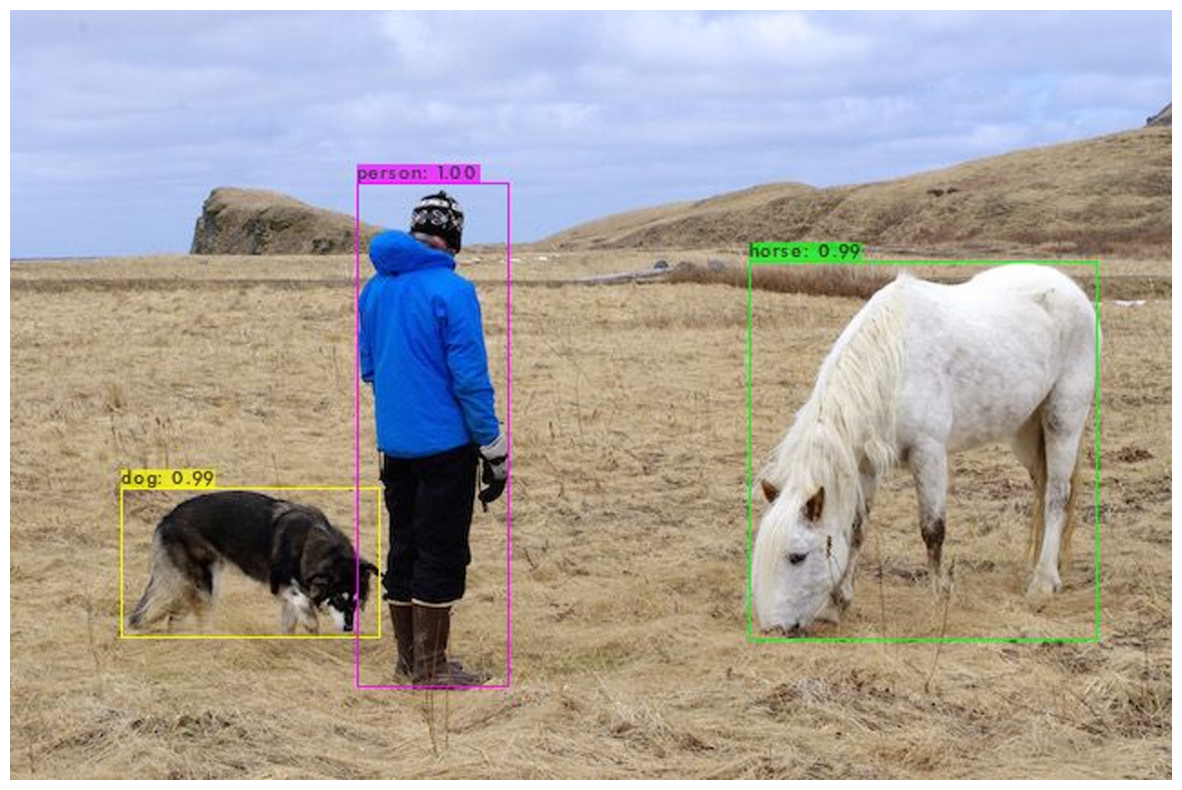

In [7]:
show_img(DARKNET_DIR / "predictions.jpg", scale=2)

### A few more images

/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/darknetv3/darknet/data/dog.jpg: Predicted in 2480.949000 milli-seconds.
bicycle: 99%
dog: 99%
truck: 91%
car: 27%


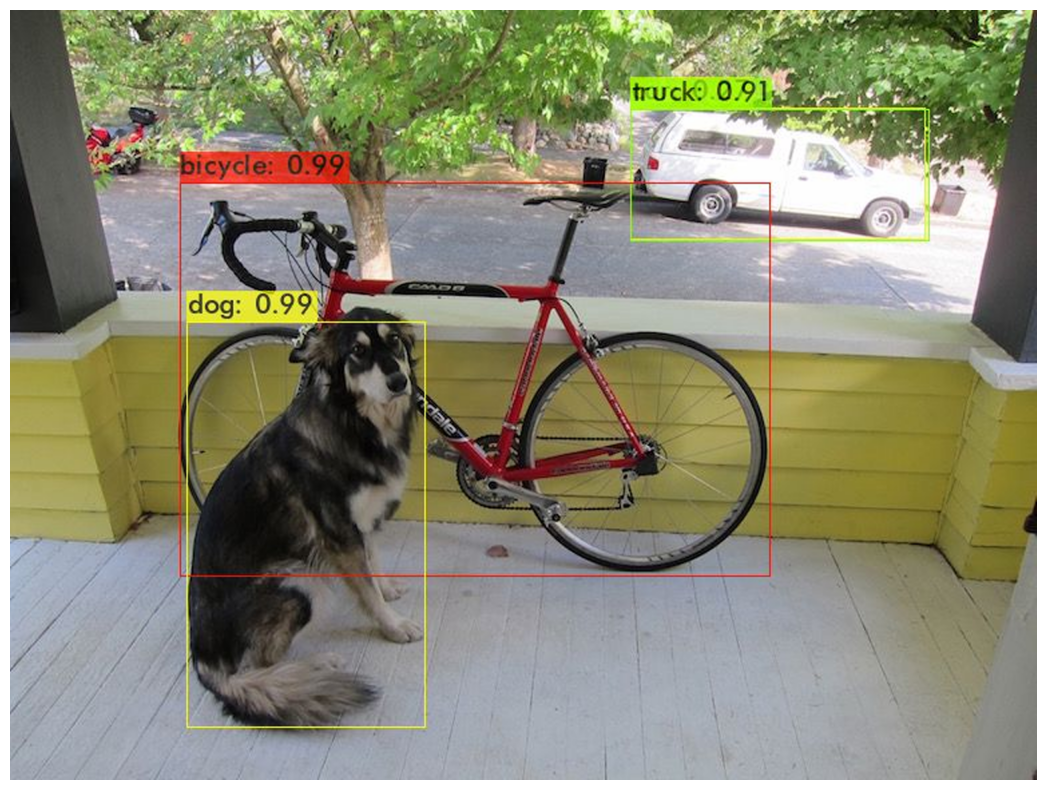

/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/darknetv3/darknet/data/horses.jpg: Predicted in 2549.138000 milli-seconds.
horse: 100%
horse: 32%
horse: 71%
horse: 90%
horse: 96%
horse: 100%


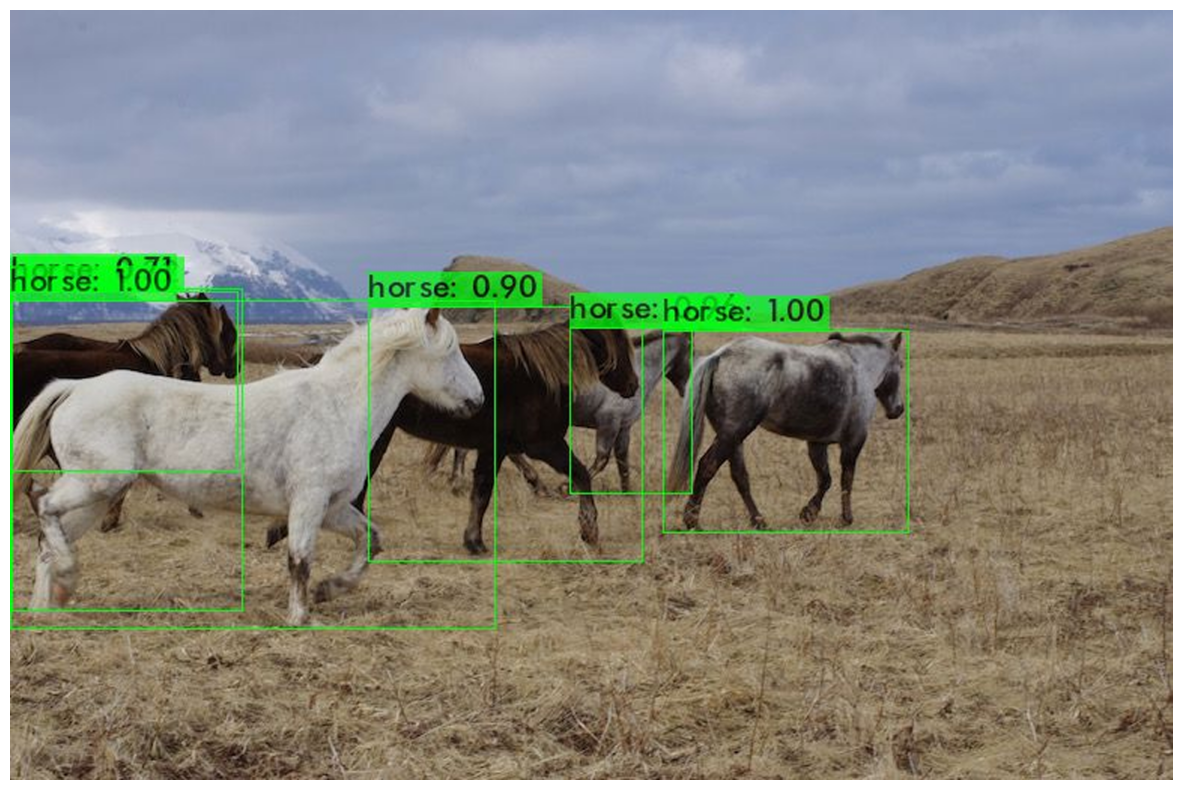

/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/darknetv3/darknet/data/eagle.jpg: Predicted in 2642.770000 milli-seconds.
bird: 98%


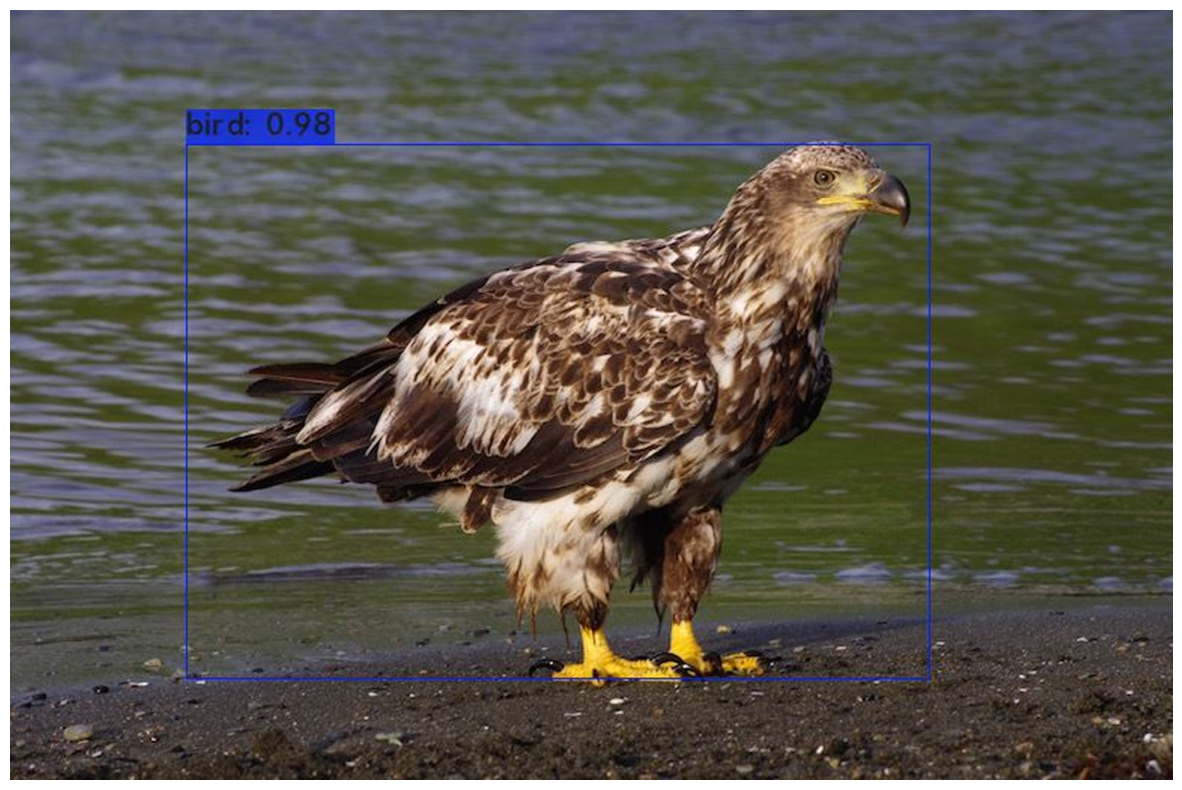

/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/darknetv3/darknet/data/giraffe.jpg: Predicted in 2538.237000 milli-seconds.
giraffe: 99%
zebra: 100%


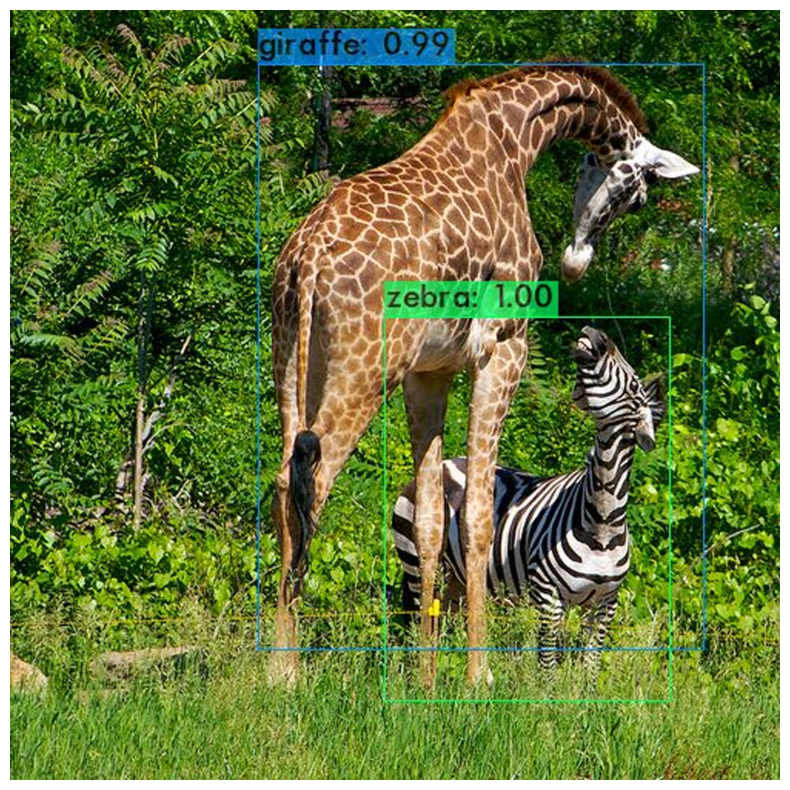

In [8]:
samples = ["dog.jpg", "horses.jpg", "eagle.jpg", "giraffe.jpg"]

for name in samples:
    img = DARKNET_DIR / "data" / name
    if not img.exists():
        print("skip (missing):", name)
        continue
    os.chdir(DARKNET_DIR)
    !"{DARKNET_BIN}" detector test "{COCO_DATA}" "{INFER_CFG}" "{staged_v4}" \
        "{img}" -dont_show -thresh 0.25 2>&1 | grep -E "Predicted|%" | head -8
    os.chdir(MODULE_DIR)
    show_img(DARKNET_DIR / "predictions.jpg", scale=2)

## Loading data to VM — the custom dataset

The lesson copies eight things out of Drive into the darknet folder:

```python
!cp -r "/content/gdrive/My Drive/Colab/darknetv4/darknet/img"  ./img
!cp -r "/content/gdrive/My Drive/Colab/darknetv4/yolov4-robots.cfg"  ./cfg/
!cp -r "/content/gdrive/My Drive/Colab/darknetv4/train.txt"  ./data/
!cp -r "/content/gdrive/My Drive/Colab/darknetv4/test.txt"   ./data/
!cp -r "/content/gdrive/My Drive/Colab/darknetv4/robots-obj.data"   ./data/
!cp -r "/content/gdrive/My Drive/Colab/darknetv4/robots-obj.names"  ./data/
!cp -r "/content/gdrive/My Drive/Colab/darknetv4/yolov4.conv.137"   ./
```

The YOLOv4 versions of these live in `code/5-Object_Detection/darknetv4/`, and
the images are the same 213-image r2d2/c3po set used by notebook 19. Note the
v4 lesson puts the lists under `data/`, so `robots-obj.data` reads
`train = data/train.txt` rather than `train.txt`.

**Why the image folder is `img` and not `images`:** darknet derives each label
path from its image path by swapping `.jpg` -> `.txt` *and* replacing a
`/images/` component with `/labels/`. The dataset keeps `000000.jpg` and
`000000.txt` side by side in one folder, so that second substitution must not
fire. `img` avoids the word entirely.

In [9]:
IMAGES_DIR = DARKNETV3 / "images"           # 213 .jpg + matching .txt
IMG_LINK   = DARKNET_DIR / "img"
DATA_DIR   = DARKNET_DIR / "data"

if not IMG_LINK.exists():
    IMG_LINK.symlink_to(os.path.relpath(IMAGES_DIR, DARKNET_DIR))

# cfg/yolov4-robots.cfg
V4_CUSTOM_CFG = DARKNET_DIR / "cfg" / "yolov4-robots.cfg"
shutil.copyfile(DARKNETV4 / "yolov4-robots.cfg", V4_CUSTOM_CFG)

# data/robots-obj.names
v4_names = DATA_DIR / "robots-obj.names"
shutil.copyfile(DARKNETV4 / "robots-obj.names", v4_names)
CLASSES = v4_names.read_text().split()

# data/train.txt and data/test.txt -- keep only paths that resolve
def stage_list(name):
    kept = [l for l in (DARKNETV3 / name).read_text().split()
            if (DARKNET_DIR / l).exists()]
    (DATA_DIR / name).write_text("\n".join(kept) + "\n")
    return kept

train_list = stage_list("train.txt")
test_list = stage_list("test.txt")

# data/robots-obj.data
v4_data = DATA_DIR / "robots-obj.data"
v4_data.write_text(
    "classes = {}\n"
    "train  = data/train.txt\n"
    "valid  = data/test.txt\n"
    "names  = data/robots-obj.names\n"
    "backup = backup\n".format(len(CLASSES)))

print("classes  :", CLASSES)
print("train    :", len(train_list), "images")
print("test     :", len(test_list), "images")
print()
print(v4_data.read_text())

classes  : ['r2d2', 'c3po']
train    : 180 images
test     : 33 images

classes = 2
train  = data/train.txt
valid  = data/test.txt
names  = data/robots-obj.names
backup = backup



## `yolov4-robots.cfg` — the six edits

The lesson's slide, applied to a copy of `yolov4-custom.cfg`:

1. Copy `yolov4-custom.cfg` and rename it `yolov4-robots.cfg`
2. `max_batches = classes * 2000` — 2 classes gives **4000** (line 20)
3. `steps = 0.8 * max_batches, 0.9 * max_batches` — **3200, 3600** (line 22)
4. `width=416 height=416` for training (lines 8-9)
5. `classes=` your class count, in each of the **3** `[yolo]` layers
6. `filters = (classes + 5) x 3` in the convolutional layer immediately before
   each `[yolo]` — **21** for 2 classes, against COCO's 255

Note YOLOv4 uses `(classes + 5) x 3`, the same formula as YOLOv3 — 3 anchor
boxes per scale, 4 box offsets plus 1 objectness. Missing even one of the three
is the usual reason a custom cfg fails to load.

The next cell checks the file rather than trusting it.

In [10]:
lines = V4_CUSTOM_CFG.read_text().splitlines()
n_classes = len(CLASSES)
expected = (n_classes + 5) * 3

heads, ok = [], True
for i, line in enumerate(lines):
    if line.strip() != "[yolo]":
        continue
    cls = next((int(l.split("=")[1].split("#")[0]) for l in lines[i:i + 25]
                if l.strip().startswith("classes=")), None)
    flt = next((int(l.split("=")[1].split("#")[0]) for l in reversed(lines[:i])
                if l.strip().startswith("filters=")), None)
    heads.append((i + 1, cls, flt))
    if cls != n_classes or flt != expected:
        ok = False

def setting(key):
    return next((l.split("=")[1].split("#")[0].strip()
                 for l in lines[:40] if l.strip().startswith(key + "=") or
                 l.strip().startswith(key + " =")), "?")

print(f"{n_classes} classes -> filters = ({n_classes} + 5) x 3 = {expected}")
print(f"max_batches = {setting('max_batches')}   (classes x 2000)")
print(f"steps       = {setting('steps')}   (0.8 / 0.9 x max_batches)")
print(f"input size  = {setting('width')}x{setting('height')}")
print(f"\n{len(heads)} [yolo] heads:")
for lineno, cls, flt in heads:
    print(f"  {'OK ' if (cls == n_classes and flt == expected) else 'BAD'} "
          f"line {lineno:5d}: classes={cls}, preceding filters={flt}")
print("\ncfg is consistent" if ok else "\ncfg MISMATCH -- fix before training")

2 classes -> filters = (2 + 5) x 3 = 21
max_batches = 4000   (classes x 2000)
steps       = 3200,3600   (0.8 / 0.9 x max_batches)
input size  = 416x416

3 [yolo] heads:
  OK  line   967: classes=2, preceding filters=21
  OK  line  1055: classes=2, preceding filters=21
  OK  line  1143: classes=2, preceding filters=21

cfg is consistent


## Training the custom dataset

The lesson's commands — the first starts from the pretrained backbone, the
second resumes from the last checkpoint:

```bash
!./darknet detector train data/robots-obj.data cfg/yolov4-robots.cfg weights/yolov4.conv.137 -dont_show
#!./darknet detector train data/robots-obj.data cfg/yolov4-robots.cfg ./backup/yolov4-robots_last.weights -dont_show
```

On the lesson's GPU this reports `863: 1.77 avg loss ... 5.7 hours left` for 4000
iterations.

**This is not practical here.** The build is `GPU=0`, and CPU YOLOv4 training is
orders of magnitude slower — the estimate would be weeks, not hours. Unlike
notebook 19, there is also **no pre-trained custom YOLOv4 checkpoint in this
repo** (`darknetv4/` has the cfg and the lists, but no `backup/` weights), so
the custom-model video from the lesson cannot be reproduced locally without
training it.

You would also need `yolov4.conv.137` (162 MB), the pretrained backbone:

```bash
curl -LO https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.conv.137
```

The cell is left guarded and off.

In [11]:
RUN_TRAINING = False       # CPU-only: weeks, not hours

backbone = DARKNET_DIR / "yolov4.conv.137"
custom_weights = DARKNET_DIR / "backup" / "yolov4-robots_last.weights"

if RUN_TRAINING:
    if not backbone.exists():
        raise SystemExit(f"missing backbone: {backbone} -- see the curl command above")
    (DARKNET_DIR / "backup").mkdir(exist_ok=True)
    os.chdir(DARKNET_DIR)
    !"{DARKNET_BIN}" detector train data/robots-obj.data cfg/yolov4-robots.cfg "{backbone}" -dont_show
    os.chdir(MODULE_DIR)
else:
    print("Training skipped (RUN_TRAINING = False).")
    print("backbone yolov4.conv.137:", "present" if backbone.exists() else "missing")
    print("trained custom weights  :", "present" if custom_weights.exists() else
          "missing -- the video below uses the COCO model instead")

Training skipped (RUN_TRAINING = False).
backbone yolov4.conv.137: missing
trained custom weights  : missing -- the video below uses the COCO model instead


## Testing on video

The lesson's command:

```bash
!./darknet detector demo data/robots-obj.data cfg/yolov4-robots.cfg \
    ./backup/yolov4-robots_last.weights -dont_show R2D2.avi -i 0 -out_filename robots_yolov4.mp4
```

Two things prevent that running verbatim here, and the cell below handles both:

* `detector demo` decodes and writes video **through OpenCV**, and this darknet
  is `OPENCV=0`. So frames are fed through `detector test` instead and drawn with
  `cv2` — same output file, no rebuild.
* There is no trained `yolov4-robots_last.weights`, so it falls back to the
  **COCO** model, which detects `person`, `tie`, `chair` and so on rather than
  `r2d2`/`c3po`. If you ever do train the custom model, set `USE_CUSTOM = True`.

**Timing.** At 416x416 the measured cost is 2.44 s/frame. `FRAME_STEP = 10`
samples every 10th frame of the 2451-frame clip — 246 frames, about **10
minutes** — and writes at a tenth of the source frame rate, so the result still
covers the whole clip and plays for its full 2:02.

In [12]:
VIDEO_SRC  = DARKNETV3 / "R2D2.avi"
VIDEO_OUT  = MODULE_DIR / "videos_out" / "robots_yolov4.mp4"
FRAME_STEP = 10          # 1 = every frame (~100 min at 416)
MAX_FRAMES = 0           # 0 = whole clip
USE_CUSTOM = False       # True once a trained yolov4-robots checkpoint exists

if USE_CUSTOM and custom_weights.exists():
    DATA_FILE, CFG_FILE, WEIGHTS_FILE = v4_data, V4_CUSTOM_CFG, custom_weights
    COLORS = {"r2d2": (255, 0, 255), "c3po": (0, 255, 128)}
else:
    DATA_FILE, CFG_FILE, WEIGHTS_FILE = COCO_DATA, INFER_CFG, staged_v4
    COLORS = {}
    print("Using the COCO model (no trained custom weights available).\n")

VIDEO_OUT.parent.mkdir(exist_ok=True)

PRED_RE = re.compile(r"^(?P<path>.+?): Predicted in [\d.]+ milli-seconds\.")
BOX_RE = re.compile(
    r"^(?P<label>.+?): (?P<conf>\d+)%\s*"
    r"\(left_x:\s*(?P<x>-?\d+)\s+top_y:\s*(?P<y>-?\d+)\s+"
    r"width:\s*(?P<w>-?\d+)\s+height:\s*(?P<h>-?\d+)\)")


def darknet_detect(image_paths, thresh=0.3):
    """One darknet process for many images -- paths go in on stdin."""
    image_paths = [str(p) for p in image_paths]
    proc = subprocess.run(
        [str(DARKNET_BIN), "detector", "test", str(DATA_FILE), str(CFG_FILE),
         str(WEIGHTS_FILE), "-dont_show", "-ext_output", "-thresh", str(thresh)],
        input="\n".join(image_paths) + "\n",
        capture_output=True, text=True, cwd=str(DARKNET_DIR))

    results = {p: [] for p in image_paths}
    current = None
    for raw in proc.stdout.splitlines():
        line = raw.strip()
        if line.startswith("Enter Image Path:"):
            line = line[len("Enter Image Path:"):].strip()
        m = PRED_RE.match(line)
        if m:
            current = m.group("path")
            results.setdefault(current, [])
            continue
        m = BOX_RE.match(line)
        if m and current is not None:
            results[current].append((
                m.group("label"), int(m.group("conf")) / 100,
                int(m.group("x")), int(m.group("y")),
                int(m.group("w")), int(m.group("h"))))
    return results


def color_for(label):
    if label in COLORS:
        return COLORS[label]
    h = abs(hash(label))                       # stable colour per class name
    return (h % 200 + 55, (h // 200) % 200 + 55, (h // 40000) % 200 + 55)


def draw(image_bgr, detections):
    out = image_bgr.copy()
    for label, confidence, x, y, w, h in detections:
        col = color_for(label)
        cv2.rectangle(out, (x, y), (x + w, y + h), col, 3)
        cv2.putText(out, f"{label} ({confidence * 100:.0f}%)",
                    (x, max(y - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, col, 2)
    return out


print("model :", CFG_FILE.name, "+", Path(WEIGHTS_FILE).name)

Using the COCO model (no trained custom weights available).

model : yolov4-416.cfg + yolov4.weights


In [ ]:
cap = cv2.VideoCapture(str(VIDEO_SRC))
if not cap.isOpened():
    raise RuntimeError(f"cannot open {VIDEO_SRC}")

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS) or 20.0
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

tmpdir = Path(tempfile.mkdtemp(prefix="yolov4_"))
started = time.time()
try:
    frame_paths, index = [], 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if index % FRAME_STEP == 0:
            p = tmpdir / f"{len(frame_paths):06d}.jpg"
            cv2.imwrite(str(p), frame)
            frame_paths.append(p)
            if MAX_FRAMES and len(frame_paths) >= MAX_FRAMES:
                break
        index += 1
    cap.release()

    per_frame = {608: 5.3, 416: 2.44, 320: 1.34}.get(NET_SIZE, 2.5)
    print(f"{len(frame_paths)} frames sampled from {total} "
          f"(~{len(frame_paths) * per_frame / 60:.0f} min at {NET_SIZE}x{NET_SIZE}) ...")

    detections = darknet_detect(frame_paths)

    # HTML5 <video> decodes H.264 only; 'mp4v' would write MPEG-4 Part 2 and the
    # notebook player would stay blank.
    writer = cv2.VideoWriter(str(VIDEO_OUT), cv2.VideoWriter_fourcc(*"avc1"),
                             fps / FRAME_STEP, (width, height))
    hits, labels = 0, {}
    for p in frame_paths:
        boxes = detections.get(str(p), [])
        hits += len(boxes)
        for lab, *_ in boxes:
            labels[lab] = labels.get(lab, 0) + 1
        writer.write(draw(cv2.imread(str(p)), boxes))
    writer.release()

    print(f"\nwrote {VIDEO_OUT.name}: {len(frame_paths)} frames, {hits} detections, "
          f"{(time.time() - started) / 60:.1f} min")
    for lab, n in sorted(labels.items(), key=lambda kv: -kv[1])[:10]:
        print(f"   {lab:15s} {n}")
finally:
    shutil.rmtree(tmpdir, ignore_errors=True)

246 frames sampled from 2451 (~10 min at 416x416) ...


In [ ]:
from IPython.display import Video

Video(str(VIDEO_OUT.relative_to(MODULE_DIR)), embed=True, width=720)

### A single annotated frame

Quicker to eyeball than scrubbing the video.

In [ ]:
cap = cv2.VideoCapture(str(VIDEO_OUT))
cap.set(cv2.CAP_PROP_POS_FRAMES, 20)
ok, frame = cap.read()
cap.release()

if ok:
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
else:
    print("could not read a frame back")

## Note

From the lesson:

> After training, to boost performance increase the network resolution in
> `yolov4-robots.cfg` to 608x608 or 832x832 — this makes it possible to detect
> small objects.

That applies here too, with the caveat from the benchmark above: on CPU, 608
costs 5.3 s/frame against 2.44 s at 416, so raise it for accuracy on stills and
leave it low for video.

The lesson closes by printing the TensorFlow version (2.3.0 on Colab). Nothing
in this notebook uses TensorFlow — darknet is standalone C — but for reference:

In [ ]:
import tensorflow as tf

print(tf.__version__)
print("Metal GPU devices:", tf.config.list_physical_devices("GPU"))

---

# Example: YOLOv4 on `miami.mp4`

The COCO model on a street scene — the kind of clip the course uses to show off
YOLOv4's 80 classes (person, car, bus, truck, traffic light, handbag, umbrella
and so on).

**About this `miami.mp4`.** There is no canonical "miami.mp4" in the
darknet/YOLO world — the course's clip is the instructor's own and is not
published anywhere. The file in this folder is a freely licensed stand-in:
[Street traffic.webm](https://commons.wikimedia.org/wiki/File:Street_traffic.webm)
from Wikimedia Commons (CC BY 3.0), transcoded to H.264 and scaled to 1280x720.
Attribution is recorded in `miami.mp4.LICENSE.txt`. Swap in any other clip of
that name and everything still works.

**Timing is budgeted, not fixed.** `TARGET_MINUTES` sets how long you are willing
to wait and the frame step is derived from it, using the measured cost for the
current `NET_SIZE`. So the default finishes in roughly 5 minutes whether the clip
is 350 frames or 3500. Set `TARGET_MINUTES` higher for a smoother result.

In [ ]:
MIAMI = MODULE_DIR / "miami.mp4"

if MIAMI.exists():
    SRC = MIAMI
else:
    fallbacks = ["cars.mp4", "people.mp4", "motorbikes.mp4", "bikes.mp4"]
    SRC = next((MODULE_DIR / f for f in fallbacks if (MODULE_DIR / f).exists()), None)
    if SRC is None:
        raise SystemExit("no street-scene video found -- add miami.mp4 to this folder")
    print(f"miami.mp4 not found -- using {SRC.name} instead.")
    print("Drop miami.mp4 in this folder and re-run to use the real clip.\n")

TARGET_MINUTES = 5        # how long you are willing to wait
OUT = MODULE_DIR / "videos_out" / f"{SRC.stem}-yolov4.mp4"

cap = cv2.VideoCapture(str(SRC))
if not cap.isOpened():
    raise RuntimeError(f"cannot open {SRC}")
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# derive the frame step from the time budget and the measured per-frame cost
COST = {608: 5.3, 416: 2.44, 320: 1.34}.get(NET_SIZE, 2.5)
affordable = max(int(TARGET_MINUTES * 60 / COST), 1)
STEP = max(1, -(-total // affordable))          # ceil(total / affordable)
n_frames = -(-total // STEP)

print(f"{SRC.name}: {total} frames, {w}x{h} @ {fps:.0f} fps")
print(f"budget {TARGET_MINUTES} min at {COST}s/frame -> every {STEP} frame(s) "
      f"= {n_frames} frames (~{n_frames * COST / 60:.1f} min)")

# make sure we are pointed at the COCO model, not a custom one
DATA_FILE, CFG_FILE, WEIGHTS_FILE = COCO_DATA, INFER_CFG, staged_v4
COLORS = {}

OUT.parent.mkdir(exist_ok=True)
tmpdir = Path(tempfile.mkdtemp(prefix="miami_"))
started = time.time()
try:
    frames, i = [], 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if i % STEP == 0:
            p = tmpdir / f"{len(frames):06d}.jpg"
            cv2.imwrite(str(p), frame)
            frames.append(p)
        i += 1
    cap.release()

    per_frame = {608: 5.3, 416: 2.44, 320: 1.34}.get(NET_SIZE, 2.5)
    print(f"{len(frames)} frames sampled (~{len(frames) * per_frame / 60:.0f} min) ...")

    dets = darknet_detect(frames, thresh=0.35)

    writer = cv2.VideoWriter(str(OUT), cv2.VideoWriter_fourcc(*"avc1"),
                             fps / STEP, (w, h))
    hits, labels = 0, {}
    for p in frames:
        boxes = dets.get(str(p), [])
        hits += len(boxes)
        for lab, *_ in boxes:
            labels[lab] = labels.get(lab, 0) + 1
        writer.write(draw(cv2.imread(str(p)), boxes))
    writer.release()

    print(f"\nwrote {OUT.name}: {len(frames)} frames, {hits} detections, "
          f"{(time.time() - started) / 60:.1f} min")
    print("\nclasses detected:")
    for lab, n in sorted(labels.items(), key=lambda kv: -kv[1]):
        print(f"   {lab:16s} {n}")
finally:
    shutil.rmtree(tmpdir, ignore_errors=True)

In [ ]:
from IPython.display import Video

Video(str(OUT.relative_to(MODULE_DIR)), embed=True, width=720)

### A frame from the result

In [ ]:
cap = cv2.VideoCapture(str(OUT))
cap.set(cv2.CAP_PROP_POS_FRAMES, 30)
ok, frame = cap.read()
cap.release()

if ok:
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"{OUT.name} - YOLOv4 COCO @ {NET_SIZE}x{NET_SIZE}")
    plt.axis("off")
    plt.show()
else:
    print("could not read a frame back")